In [1]:
%load_ext autoreload
%autoreload 2

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, classification_report, recall_score, precision_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

from mra_midas_skin_cancer_ml.utils.merge_image_pred import merge_image_pred
from mra_midas_skin_cancer_ml.utils.load_metadata_pred import load_pred_file

from mra_midas_skin_cancer_ml.utils.process_metadata import (
    create_lesion_key,
    dedupe_metadata,
    drop_na_target_img,
    import_metadata,
    process_target,
    get_data_dir,
    export_metadata,
)

# Merge Prediction Results

In [3]:
# Merge image prediction results
image_pred_dfs = merge_image_pred()

for split, df in image_pred_dfs.items():
    print(f"Displaying {split} split:")
    display(df.head(3))

Length of 1ft-train key rows: 830
Length of 1ft-train pred rows: 830
Length of 1ft-train merged rows: 830
Length of 1ft-val key rows: 100
Length of 1ft-val pred rows: 100
Length of 1ft-val merged rows: 100
Length of 1ft-test key rows: 91
Length of 1ft-test pred rows: 91
Length of 1ft-test merged rows: 91
Length of 1ft combined rows: 1021
Length of 6in-train key rows: 833
Length of 6in-train pred rows: 833
Length of 6in-train merged rows: 833
Length of 6in-val key rows: 101
Length of 6in-val pred rows: 101
Length of 6in-val merged rows: 101
Length of 6in-test key rows: 94
Length of 6in-test pred rows: 94
Length of 6in-test merged rows: 94
Length of 6in combined rows: 1028
Length of dscope-train key rows: 834
Length of dscope-train pred rows: 834
Length of dscope-train merged rows: 834
Length of dscope-val key rows: 101
Length of dscope-val pred rows: 101
Length of dscope-val merged rows: 101
Length of dscope-test key rows: 93
Length of dscope-test pred rows: 93
Length of dscope-test mer

,lesion_key,midas_record_id,midas_file_name,matched_file,midas_path_binary,split,1ft_malignant_probability,1ft_prediction_label
0,1_chest_8.0x5.0,1,s-prd-398966407.jpg,s-prd-398966407.jpg,malignant,train,0.550893,malignant
1,1_l lower back_6.0x5.0,1,s-prd-398967381.jpg,s-prd-398967381.jpg,benign,train,0.606678,malignant
2,1_left upper buttock_5.0x3.0,1,s-prd-398968016.jpg,s-prd-398968016.jpg,benign,train,0.480606,malignant


Displaying 6in split:


,lesion_key,midas_record_id,midas_file_name,matched_file,midas_path_binary,split,6in_malignant_probability,6in_prediction_label
0,1_chest_8.0x5.0,1,s-prd-398966642.jpg,s-prd-398966642.jpg,malignant,train,0.583346,malignant
1,1_left upper buttock_5.0x3.0,1,s-prd-398968141.jpg,s-prd-398968141.jpg,benign,train,0.361439,benign
2,2_right upper eyelid_4.0x2.0,2,s-prd-399001840.jpg,s-prd-399001840_cropped.jpg,benign,train,0.387896,benign


Displaying dscope split:


,lesion_key,midas_record_id,midas_file_name,matched_file,midas_path_binary,split,dscope_malignant_probability,dscope_prediction_label
0,1_chest_8.0x5.0,1,s-prd-398966845.jpg,s-prd-398966845.jpg,malignant,train,0.966925,malignant
1,1_l lower back_6.0x5.0,1,s-prd-398967587.jpg,s-prd-398967587.jpg,benign,train,0.273244,benign
2,2_right upper eyelid_4.0x2.0,2,s-prd-399002046.jpg,s-prd-399002046.jpg,benign,train,0.514993,malignant


In [4]:
metadata_pred_df = load_pred_file()
metadata_pred_df.head()

,lesion_key,midas_path_binary,split,malignant_probability,metadata_prediction_label
0,1_chest_8.0x5.0,malignant,train,0.626450,malignant
1,1_l lower back_6.0x5.0,benign,train,0.478397,benign
2,1_left upper buttock_5.0x3.0,benign,test,0.586026,malignant
3,2_right upper eyelid_4.0x2.0,benign,test,0.226756,benign
4,4_left upper back_5.0x3.0,benign,train,0.276338,benign


In [5]:
def evaluate_predictions(y_true, y_prob, threshold=0.4):
    y_pred = (y_prob >= threshold).astype(int)

    print(f"Threshold: {threshold}")
    print(f"ROC AUC: {roc_auc_score(y_true, y_prob):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    return y_pred

# Metadata Dataframe for Eval

In [6]:
meta_df = import_metadata()
meta_df = process_target(meta_df)
dedupe_df = dedupe_metadata(meta_df)

split_lookup_path = 'master_lesion_split_lookup.xlsx'
lesion_split_lookup = pd.read_excel(split_lookup_path)
metadata_df = dedupe_df.merge(
    lesion_split_lookup[['lesion_key', 'split']], 
    on='lesion_key',
    how='inner'
)

metadata_df

Is unique: True
Unique count: 1146 



,midas_path_binary,midas_record_id,midas_location,midas_age,midas_fitzpatrick,midas_race,length_(mm),width_(mm),lesion_key,split
0,malignant,1,chest,80,"ii fair skin, blue eyes",white,8.0,5.0,1_chest_8.0x5.0,train
1,benign,1,l lower back,80,"ii fair skin, blue eyes",white,6.0,5.0,1_l lower back_6.0x5.0,train
2,benign,1,left upper buttock,80,"ii fair skin, blue eyes",white,5.0,3.0,1_left upper buttock_5.0x3.0,test
3,benign,2,right upper eyelid,34,"ii fair skin, blue eyes",white,4.0,2.0,2_right upper eyelid_4.0x2.0,test
4,benign,4,left upper back,47,"i pale white skin, blue/green eyes, blond/red ...",white,5.0,3.0,4_left upper back_5.0x3.0,train
...,...,...,...,...,...,...,...,...,...,...
1030,malignant,805,mid upper back,81,"ii fair skin, blue eyes",white,15.0,10.0,805_mid upper back_15.0x10.0,train
1031,malignant,806,l leg,64,"ii fair skin, blue eyes",white,8.0,5.0,806_l leg_8.0x5.0,train
1032,malignant,807,right calf,65,"ii fair skin, blue eyes",white,4.5,3.0,807_right calf_4.5x3.0,train
1033,benign,809,back,64,"ii fair skin, blue eyes",white,5.0,5.0,809_back_5.0x5.0,train


# Model \#1 \- Gridsearch on Optimal Fusion Weights

In [7]:
# Load the metadata predictions

metadata_pred_df = load_pred_file()
metadata_pred_df.head()

,lesion_key,midas_path_binary,split,malignant_probability,metadata_prediction_label
0,1_chest_8.0x5.0,malignant,train,0.626450,malignant
1,1_l lower back_6.0x5.0,benign,train,0.478397,benign
2,1_left upper buttock_5.0x3.0,benign,test,0.586026,malignant
3,2_right upper eyelid_4.0x2.0,benign,test,0.226756,benign
4,4_left upper back_5.0x3.0,benign,train,0.276338,benign


In [8]:
def multimodal_df():
    """
    Combine the three image prediction sets and metadata predictions into a single dataframe.
    """
    fusion_df = (
        image_pred_dfs["1ft"]
            .merge(
                image_pred_dfs["6in"][[
                    "lesion_key",
                    "6in_malignant_probability"
                ]],
                on="lesion_key",
                how="inner"
            )
            .merge(
                image_pred_dfs["dscope"][[
                    "lesion_key",
                    "dscope_malignant_probability"
                ]],
                on="lesion_key",
                how="inner"
            )
            .merge(
                metadata_pred_df[[
                    "lesion_key",
                    "malignant_probability"
                ]],
                on="lesion_key",
                how="inner"
            )
    )

    cols_to_drop = [
    "midas_record_id",
    "midas_file_name",
    "matched_file",
    "1ft_prediction_label",
    ]

    fusion_df = fusion_df.drop(columns=cols_to_drop, errors="ignore")

    # Convert target to binary 0/1
    fusion_df["midas_path_binary"] = (
        fusion_df["midas_path_binary"]
            .map({"benign": 0, "malignant": 1})
    )

    print("Fusion dataframe shape:", fusion_df.shape)
    print("\nMissing values:")
    display(fusion_df.isna().sum())

    return fusion_df


In [9]:
fusion_df = multimodal_df()
fusion_df.head()

Fusion dataframe shape: (1013, 7)

Missing values:


lesion_key                      0
midas_path_binary               0
split                           0
1ft_malignant_probability       0
6in_malignant_probability       0
dscope_malignant_probability    0
malignant_probability           0
dtype: int64

,lesion_key,midas_path_binary,split,1ft_malignant_probability,6in_malignant_probability,dscope_malignant_probability,malignant_probability
0,1_chest_8.0x5.0,1,train,0.550893,0.583346,0.966925,0.626450
1,2_right upper eyelid_4.0x2.0,0,train,0.479004,0.387896,0.514993,0.226756
2,5_r dorsal hand _7.0x6.0,1,train,0.794812,0.586012,0.964949,0.683750
3,5_l dorsal hand _3.0x5.0,1,train,0.653289,0.745908,0.824787,0.672959
4,5_r forehead_5.0x4.0,0,train,0.650272,0.563458,0.843686,0.459061


In [10]:
fusion_df["split"] = fusion_df["split"].str.lower()

train_df = fusion_df[fusion_df["split"] == "train"].copy()
val_df   = fusion_df[fusion_df["split"] == "val"].copy()
test_df  = fusion_df[fusion_df["split"] == "test"].copy()

print(len(train_df), len(val_df), len(test_df))

822 100 91


In [11]:
def grid_search_weights(df, prob_cols, y_col="midas_path_binary"):
    """
    Gridsearch the optimal fusion weights by ROC AUC
    """

    y_true = df[y_col].values

    best_auc = 0
    best_weights = None

    weight_grid = np.linspace(0, 1, 6)

    for w1 in weight_grid:
        for w2 in weight_grid:
            for w3 in weight_grid:
                for w4 in weight_grid:
                    weights = np.array([w1, w2, w3, w4])
                    if weights.sum() == 0:
                        continue
                    weights = weights / weights.sum()

                    probs = df[prob_cols].values @ weights
                    auc = roc_auc_score(y_true, probs)

                    if auc > best_auc:
                        best_auc = auc
                        best_weights = weights

    print("Best AUC:", best_auc)
    print("Best weights:", best_weights)

    return best_weights


In [12]:
train_val_df = pd.concat([train_df, val_df])

prob_cols = [
    "1ft_malignant_probability",
    "6in_malignant_probability",
    "dscope_malignant_probability",
    "malignant_probability"
]

best_weights = grid_search_weights(train_val_df, prob_cols)

Best AUC: 0.8365362897154043
Best weights: [0.15384615 0.30769231 0.38461538 0.15384615]


In [13]:
def plot_confusion_matrix(df, threshold=0.4):
    """
    Create and display confusion matrix for fusion model.
    """

    df = df.copy()

    # Drop missing values
    df = df.dropna(subset=["midas_path_binary", "fusion_probability"])

    # Force binary format
    y_true = df["midas_path_binary"].astype(int).values
    y_prob = df["fusion_probability"].astype(float).values

    # Convert to predictions
    y_pred = (y_prob >= threshold).astype(int)

    # Debug safety checks
    assert set(np.unique(y_true)).issubset({0, 1}), "y_true not binary"
    assert len(y_true) == len(y_pred), "Length mismatch"

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Malignant"]
    )

    disp.plot(cmap="Blues")
    plt.title("Fusion Model Confusion Matrix")
    plt.show()

    return cm

In [14]:
def apply_fusion(df, prob_cols, weights):
    df = df.copy()
    df["fusion_probability"] = df[prob_cols].values @ weights
    return df

train_df = apply_fusion(train_df, prob_cols, best_weights)
val_df   = apply_fusion(val_df, prob_cols, best_weights)
test_df  = apply_fusion(test_df, prob_cols, best_weights)

In [15]:
def find_threshold_for_target_recall(y_true, y_prob, target_recall=0.95):
    thresholds = np.linspace(1, 0, 200)

    best_threshold = 0.4

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tp = ((y_true == 1) & (y_pred == 1)).sum()
        fn = ((y_true == 1) & (y_pred == 0)).sum()

        recall = tp / (tp + fn + 1e-8)

        if recall >= target_recall:
            best_threshold = t
            break

    print(f"Selected threshold: {best_threshold:.4f}")
    return best_threshold

In [16]:
val_threshold = find_threshold_for_target_recall(
    val_df["midas_path_binary"].values,
    val_df["fusion_probability"].values,
    target_recall=0.96
)

Selected threshold: 0.3769


In [17]:
evaluate_predictions(
    test_df["midas_path_binary"].values,
    test_df["fusion_probability"].values,
    threshold=val_threshold
)

Threshold: 0.37688442211055273
ROC AUC: 0.7737
Precision: 0.5375
Recall: 0.9773

Confusion Matrix:
[[10 37]
 [ 1 43]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.21      0.34        47
           1       0.54      0.98      0.69        44

    accuracy                           0.58        91
   macro avg       0.72      0.60      0.52        91
weighted avg       0.73      0.58      0.51        91



array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0])

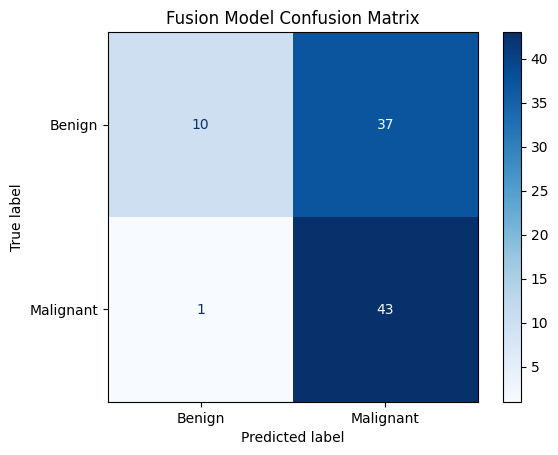

array([[10, 37],
       [ 1, 43]])

In [18]:
plot_confusion_matrix(test_df, threshold=val_threshold)

In [19]:
def evaluate_by_fitzpatrick(df, prob_col, threshold, group_col="midas_fitzpatrick"):
    results = []

    df = df.dropna(subset=["midas_path_binary", prob_col, group_col]).copy()

    for group, subset in df.groupby(group_col):
        y_true = subset["midas_path_binary"].astype(int).values
        y_prob = subset[prob_col].astype(float).values
        y_pred = (y_prob >= threshold).astype(int)

        # Handle edge case: only one class present
        try:
            auc = roc_auc_score(y_true, y_prob)
        except:
            auc = np.nan

        results.append({
            "midas_fitzpatrick": group,
            "count": len(subset),
            "positive_rate": y_true.mean(),
            "auc": auc,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "accuracy": accuracy_score(y_true, y_pred)
        })

    results_df = pd.DataFrame(results).sort_values("midas_fitzpatrick")
    return results_df

In [20]:
# Bring midas_fitzpatrick back from original dataframe
test_df = test_df.merge(
    metadata_df[['lesion_key', 'midas_fitzpatrick']],
    on='lesion_key',
    how='left'
)

test_df['midas_fitzpatrick'] = test_df['midas_fitzpatrick'].fillna('Unknown')

fitz_fusion_results = evaluate_by_fitzpatrick(
    df=test_df,
    prob_col="fusion_probability",
    threshold=val_threshold 
)

fitz_fusion_results

/root/venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/root/venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/root/venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/root/venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,midas_fitzpatrick,count,positive_rate,auc,precision,recall,f1,accuracy
0,Unknown,1,1.000000,NaN,1.000000,1.000,1.000000,1.000000
1,"i pale white skin, blue/green eyes, blond/red ...",1,0.000000,NaN,0.000000,0.000,0.000000,1.000000
2,"ii fair skin, blue eyes",74,0.540541,0.738971,0.573529,0.975,0.722222,0.594595
3,iii darker white skin,5,0.200000,1.000000,0.333333,1.000,0.500000,0.600000
4,iv light brown skin,8,0.250000,0.916667,0.333333,1.000,0.500000,0.500000
5,v brown skin,1,0.000000,NaN,0.000000,0.000,0.000000,0.000000
6,vi dark brown or black skin,1,0.000000,NaN,0.000000,0.000,0.000000,0.000000


# Model \#2 \- Stacking Model

In [21]:
# Define features and target

FEATURE_COLS = [
    "1ft_malignant_probability",
    "6in_malignant_probability",
    "dscope_malignant_probability",
    "malignant_probability"  # metadata
]

TARGET = "midas_path_binary"

# Split data

fusion_df["split"] = fusion_df["split"].str.lower()

train_df = fusion_df[fusion_df["split"] == "train"].copy()
val_df   = fusion_df[fusion_df["split"] == "val"].copy()
test_df  = fusion_df[fusion_df["split"] == "test"].copy()


# Out-of-fold stacking

def generate_oof_predictions(df, feature_cols, target, n_splits=5):
    X = df[feature_cols].values
    y = df[target].values

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(df))

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train = y[train_idx]

        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)

        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

    return oof_preds

train_df["stacking_oof"] = generate_oof_predictions(
    train_df,
    FEATURE_COLS,
    TARGET
)


# Train meta model

meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(
    train_df[FEATURE_COLS],
    train_df[TARGET]
)

# Apply to val and test splits

val_df["stacking_probability"] = meta_model.predict_proba(
    val_df[FEATURE_COLS]
)[:, 1]

test_df["stacking_probability"] = meta_model.predict_proba(
    test_df[FEATURE_COLS]
)[:, 1]

# Recall-targeted threshold on val only

def find_threshold_for_target_recall(y_true, y_prob, target_recall=0.95):
    thresholds = np.linspace(1, 0, 200)

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tp = ((y_true == 1) & (y_pred == 1)).sum()
        fn = ((y_true == 1) & (y_pred == 0)).sum()

        recall = tp / (tp + fn + 1e-8)

        if recall >= target_recall:
            print(f"Selected threshold: {t:.4f}")
            return t

    return 0.0

stacking_threshold = find_threshold_for_target_recall(
    val_df[TARGET].values,
    val_df["stacking_probability"].values,
    target_recall=0.95
)

# Evaluation on the test only

def evaluate_predictions(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    print(f"Threshold: {threshold:.4f}")
    print(f"ROC AUC: {roc_auc_score(y_true, y_prob):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

evaluate_predictions(
    test_df[TARGET].values,
    test_df["stacking_probability"].values,
    stacking_threshold
)

Selected threshold: 0.1558
Threshold: 0.1558
ROC AUC: 0.7805
Recall: 0.9773
Precision: 0.5443

Confusion Matrix:
[[11 36]
 [ 1 43]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.23      0.37        47
           1       0.54      0.98      0.70        44

    accuracy                           0.59        91
   macro avg       0.73      0.61      0.54        91
weighted avg       0.74      0.59      0.53        91



In [22]:
# Bring midas_fitzpatrick back from original dataframe
test_df = test_df.merge(
    metadata_df[['lesion_key', 'midas_fitzpatrick']],
    on='lesion_key',
    how='left'
)

test_df['midas_fitzpatrick'] = test_df['midas_fitzpatrick'].fillna('Unknown')

fitz_stacking_results = evaluate_by_fitzpatrick(
    df=test_df,
    prob_col="stacking_probability",
    threshold=stacking_threshold
)

fitz_stacking_results

/root/venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/root/venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/root/venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/root/venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,midas_fitzpatrick,count,positive_rate,auc,precision,recall,f1,accuracy
0,Unknown,1,1.000000,NaN,1.000000,1.000,1.000000,1.000000
1,"i pale white skin, blue/green eyes, blond/red ...",1,0.000000,NaN,0.000000,0.000,0.000000,1.000000
2,"ii fair skin, blue eyes",74,0.540541,0.743382,0.582090,0.975,0.728972,0.608108
3,iii darker white skin,5,0.200000,1.000000,0.333333,1.000,0.500000,0.600000
4,iv light brown skin,8,0.250000,0.916667,0.333333,1.000,0.500000,0.500000
5,v brown skin,1,0.000000,NaN,0.000000,0.000,0.000000,0.000000
6,vi dark brown or black skin,1,0.000000,NaN,0.000000,0.000,0.000000,0.000000


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=82a37552-7c08-4009-87b3-14968bdb21f2' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>